<a href="https://colab.research.google.com/github/srishti-bs/Statistical-Foundations-of-Data-Science/blob/main/ResidualComparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Optimal Lambda: 0.7151723501460339


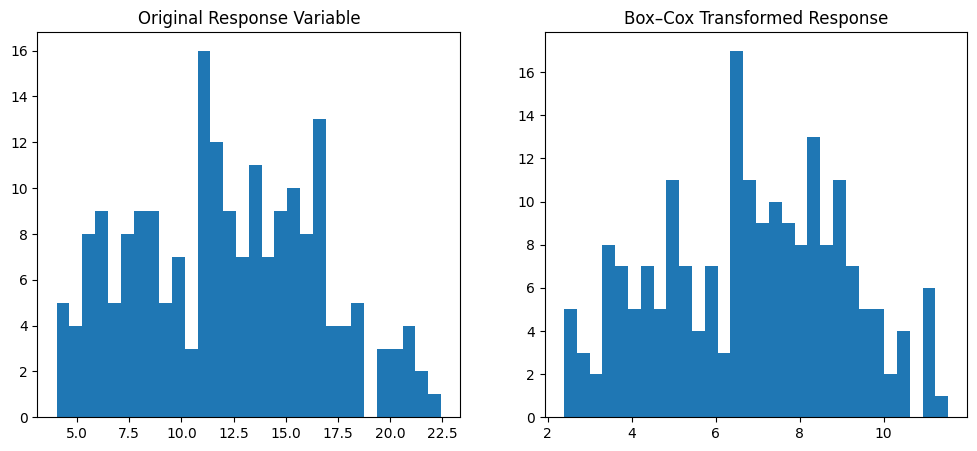

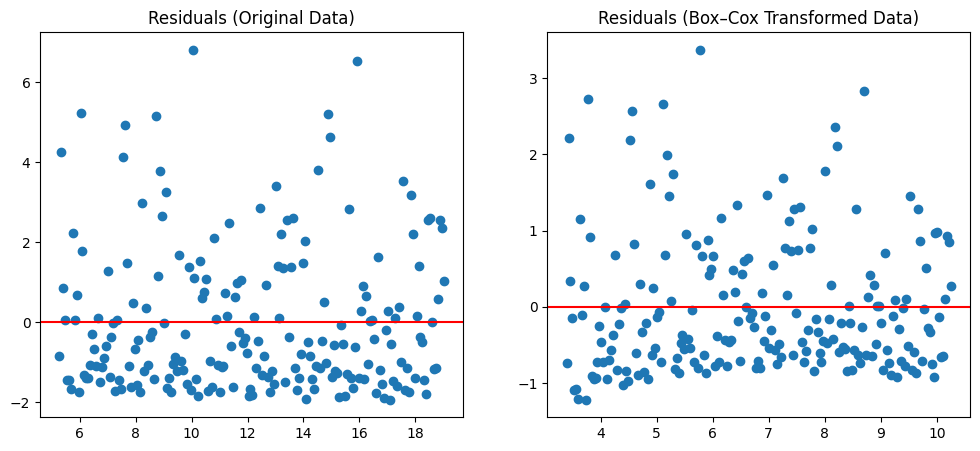

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
# Step 1: Generate skewed data
np.random.seed(42)
n = 200
X = np.linspace(1, 10, n)
errors = np.random.exponential(scale=2, size=n)
y = 2 + 1.5 * X + errors # positively skewed response
# Step 2: Fit OLS on original data
X_mat = sm.add_constant(X)
ols_original = sm.OLS(y, X_mat).fit()
# Step 3: Box–Cox transformation (y must be positive)
y_bc, lambda_opt = stats.boxcox(y)
print("Optimal Lambda:", lambda_opt)
# Step 4: Fit OLS on transformed data
ols_bc = sm.OLS(y_bc, X_mat).fit()
# Step 5: Diagnostic Plots
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(y, bins=30)
plt.title("Original Response Variable")
plt.subplot(1, 2, 2)
plt.hist(y_bc, bins=30)
plt.title("Box–Cox Transformed Response")
plt.show()
# Step 6: Residual comparison
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(ols_original.fittedvalues, ols_original.resid)
plt.axhline(0, color='red')
plt.title("Residuals (Original Data)")
plt.subplot(1, 2, 2)
plt.scatter(ols_bc.fittedvalues, ols_bc.resid)
plt.axhline(0, color='red')
plt.title("Residuals (Box–Cox Transformed Data)")
plt.show()

